# One Tight One not Tight

In [1]:
%cd ..

/afs/cern.ch/user/d/driosper/bsm3g_coffea


In [13]:
from coffea.util import load
import numpy as np
import mplhep as hep
from matplotlib.offsetbox import AnchoredText
import matplotlib.pyplot as plt
from coffea.processor import accumulate
from hist.intervals import poisson_interval
from pathlib import Path
import yaml
from analysis.filesets.utils import get_process_maps
from analysis.workflows.config import WorkflowConfigBuilder
import json
import hist
import yaml
import numpy as np
import collections
from scipy.optimize import curve_fit
from scipy.stats import f as f_dist
import matplotlib.text as mtext
import matplotlib.ticker as ticker
import matplotlib.gridspec as gridspec
hep.style.use(hep.style.CMS)

def load_hists(year,workflow):
    #out = load(f"/eos/user/d/driosper/bsm3g_coffea_outputs/{workflow}_no_ttbosted/{year}/{year}_processed_histograms.coffea")
    out = load(f"/eos/user/d/driosper/bsm3g_coffea_outputs/{workflow}/{year}/{year}_processed_histograms.coffea")
    config_builder = WorkflowConfigBuilder(workflow=workflow)
    workflow_config = config_builder.build_workflow_config()
    postprocess_dir = Path.cwd() / "analysis" / "postprocess"
    style_file = postprocess_dir / "style.yaml"
    luminosity_file = postprocess_dir / "luminosity.yaml"
    color_map_file = postprocess_dir / "color_map.yaml"
    
    with open(style_file, "r") as f:
        style = yaml.safe_load(f)
    style["rcParams"]["axes.labelsize"] = 16
    style["rcParams"]["font.size"] = 16
    style["rcParams"]["xtick.labelsize"] = 11
    style["rcParams"]["ytick.labelsize"] = 11
    with open(f"{Path.cwd()}/analysis/postprocess/luminosity.yaml", "r") as f:
        luminosities = yaml.safe_load(f)
    processes, process_name_map, _ = get_process_maps(workflow_config, year)
    with open(color_map_file, "r") as f:
        color_map = yaml.safe_load(f)
    color_map = {p: c for p, c in color_map.items() if p in processes}
    
    hep.style.use(hep.style.CMS)
    plt.rcParams.update(style["rcParams"])
    return out
    
def poly_func(x, *coefs):
    return np.polyval(coefs, x)
def fit_polynomial(x, y, yerr, degree):
    p0 = np.ones(degree + 1)
    popt, pcov = curve_fit(
        poly_func, x, y, p0=p0, sigma=yerr, absolute_sigma=True, maxfev=10000
    )
    residuals = y - poly_func(x, *popt)
    chisq = np.sum((residuals / yerr) ** 2)
    ndof = len(x) - len(popt)
    
    return popt, pcov, chisq, ndof
def find_optimal_tf_poly(x, y, yerr, max_degree=5, alpha=0.05):
    
    current_degree = 1 
    popt1, pcov1, chisq1, ndof1 = fit_polynomial(x, y, yerr, current_degree)
    for next_degree in range(2, max_degree + 1):
        try:
            popt2, pcov2, chisq2, ndof2 = fit_polynomial(x, y, yerr, next_degree)
        except RuntimeError:
            break
            
        p1 = current_degree + 1
        p2 = next_degree + 1
        n = len(x)
        
        numerator = (chisq1 - chisq2) / (p2 - p1)
        denominator = chisq2 / (n - p2)
        
        if denominator <= 0 or numerator < 0:
            break
            
        F_stat = numerator / denominator
        p_val = f_dist.sf(F_stat, p2 - p1, n - p2)
        
        if p_val < alpha:
            current_degree = next_degree
            popt1, pcov1, chisq1, ndof1 = popt2, pcov2, chisq2, ndof2
        else:
            break
            
    return current_degree, popt1, pcov1

if not hasattr(mtext.Text, "_original_init"):
    mtext.Text._original_init = mtext.Text.__init__

def _patched_text_init(self, x=0, y=0, text="", **kwargs):
    import numpy as np

    if hasattr(y, "shape") or isinstance(y, (list, tuple)):
        y = float(np.ravel(y)[0])
    if hasattr(x, "shape") or isinstance(x, (list, tuple)):
        x = float(np.ravel(x)[0])
    if isinstance(text, str) and "Preliminary" in text:
        y += 0.015
    mtext.Text._original_init(self, x, y, text, **kwargs)
mtext.Text.__init__ = _patched_text_init


def get_total_mc_uncertainty(h_mc, target_axis="muon_met_mass"):
    """Suma en cuadratura la varianza estadística y todas las variaciones sistemáticas (Up/Down)

    para el eje especificado.
    """
    # 1. Nominal (Valores y Varianza Estadística)
    h_nom = h_mc[{"variation": "nominal"}].project(target_axis)
    nom_vals = h_nom.values()
    stat_vars = (
        h_nom.variances() if h_nom.variances() is not None else nom_vals
    )

    # 2. Extraer todos los nombres de las variaciones sistemáticas
    var_axis = h_mc.axes["variation"]
    all_variations = [var_axis.value(i) for i in range(len(var_axis))]

    # Identificar nombres base de las fuentes (ej. 'CMS_btag_heavy')
    sources = set()
    for v in all_variations:
        if v == "nominal":
            continue
        if v.endswith("Up"):
            sources.add(v[:-2])
        elif v.endswith("Down"):
            sources.add(v[:-4])

    # 3. Sumar varianzas sistemáticas por cada fuente
    syst_vars = np.zeros_like(nom_vals)

    for source in sources:
        up_name = f"{source}Up"
        down_name = f"{source}Down"

        # Evaluar variación Up
        if up_name in all_variations:
            val_up = h_mc[{"variation": up_name}].project(target_axis).values()
            diff_up = np.abs(val_up - nom_vals)
        else:
            diff_up = np.zeros_like(nom_vals)

        # Evaluar variación Down
        if down_name in all_variations:
            val_down = (
                h_mc[{"variation": down_name}].project(target_axis).values()
            )
            diff_down = np.abs(val_down - nom_vals)
        else:
            diff_down = np.zeros_like(nom_vals)

        # Tomar la desviación máxima entre Up y Down (envolvente simétrica)
        max_diff = np.maximum(diff_up, diff_down)

        # Sumar en cuadratura la contribución de esta sistemática
        syst_vars += max_diff**2

    # 4. Varianza Total = Estadística + Sistemática
    total_vars = stat_vars + syst_vars
    return nom_vals, total_vars

postprocess_dir = Path.cwd() / "analysis" / "postprocess"
style_file = postprocess_dir / "style.yaml"
luminosity_file = postprocess_dir / "luminosity.yaml"
color_map_file = postprocess_dir / "color_map.yaml"
with open(luminosity_file, "r") as f:
    luminosities = yaml.safe_load(f)
with open(color_map_file, "r") as f:
    color_map = yaml.safe_load(f)
STYLE_DATA_ERR = dict(
    fmt="o", color="black", markersize=4, capsize=0, elinewidth=1.0, zorder=3
)
STYLE_TEXT_BOX = dict(
    boxstyle="round,pad=0.2", facecolor="white", alpha=0.8, edgecolor="none"
)

### TTBar DATA/MC AGREEMENT

In [3]:
def plot_panel(
    ax_main,
    ax_ratio,
    data_data,
    mc_data,
    fit_data,
    meta_info,
    desired_order,
    color_map,
):
    """Renderiza el panel principal y de ratio en un par de ejes arbitrarios."""
    # Desempaquetar datos
    centers, edges, bin_widths, data_p_gev, data_err_p_gev = data_data
    mc_p_gev, mc_err_p_gev, y_min = mc_data
    accpt, yerr_accpt, xerr, ratio_up, ratio_down = fit_data
    x_fine, y_fine, best_degree, workflow, xlabel_str, lumi_val, com_val, year = (
        meta_info
    )

    # --- PANEL PRINCIPAL ---
    ax_main.errorbar(
        centers,
        data_p_gev,
        xerr=bin_widths / 2.0,
        yerr=data_err_p_gev,
        label=r"Data $-$ Non-$t\bar{t}$ MC",
        **STYLE_DATA_ERR,
    )
    ax_main.stairs(
        values=mc_p_gev,
        edges=edges,
        fill=True,
        color=color_map["tt"],
        edgecolor="black",
        linewidth=0.8,
        label=r"$t\bar{t}$ MC",
        zorder=1,
    )
    ax_main.stairs(
        baseline=np.maximum(mc_p_gev - mc_err_p_gev, y_min),
        values=np.maximum(mc_p_gev + mc_err_p_gev, y_min),
        edges=edges,
        facecolor="lightgray",
        edgecolor="black",
        hatch="////",
        linewidth=0,
        alpha=0.8,
        label=r"Stat + Syst unc.",
        zorder=2,
    )

    ax_main.set_ylabel("Events / GeV", fontsize=12)
    ax_main.set_yscale("log")
    ax_main.set_ylim(bottom=y_min, top=np.max(data_p_gev) * 20)
    ax_main.tick_params(
        axis="x", which="both", labelbottom=False, direction="in"
    )
    ax_main.tick_params(
        axis="y", which="both", labelsize=9, direction="in"
    )

    # Leyenda ordenada
    handles, labels = ax_main.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax_main.legend(
        [by_label[l] for l in desired_order if l in by_label],
        [l for l in desired_order if l in by_label],
        loc="upper right",
        fontsize=9,
        frameon=True,
        edgecolor="black",
    )

    ax_main.text(
        0.05,
        0.88,
        f"{workflow}",
        transform=ax_main.transAxes,
        fontsize=11,
        va="top",
        ha="left",
        bbox=STYLE_TEXT_BOX,
    )

    # --- PANEL RATIO ---
    ax_ratio.fill_between(
        edges,
        ratio_up,
        ratio_down,
        step="pre",
        color="lightgray",
        alpha=0.6,
        zorder=1,
    )
    ax_ratio.axhline(
        1.0, color="k", linestyle=":", linewidth=0.8, alpha=0.8, zorder=2
    )
    ax_ratio.errorbar(
        centers,
        accpt,
        xerr=xerr,
        yerr=yerr_accpt,
        label=r"Data / MC $t\bar{t}$",
        **STYLE_DATA_ERR,
    )
    ax_ratio.plot(
        x_fine,
        y_fine,
        color="red",
        ls="-",
        lw=1.5,
        zorder=4,
        label=f"Fit (degree {best_degree})",
    )

    ax_ratio.set_ylabel(
        r"$\mu_{t\bar{t}}=\frac{\mathrm{Data}-\mathrm{non}\,t\bar{t}\,\mathrm{MC}}{t\bar{t}\,\mathrm{MC}}$",
        fontsize=10,
    )
    ax_ratio.set_xlabel(xlabel_str, fontsize=12)
    ax_ratio.set_xlim(edges[0], edges[-1])
    ax_ratio.set_ylim(0.5, 1.5)

    ax_ratio.yaxis.set_major_locator(
        ticker.MaxNLocator(nbins=4, prune="upper")
    )
    ax_ratio.tick_params(
        axis="both",
        which="both",
        direction="in",
        top=True,
        right=True,
        labelsize=9,
    )

    hep.cms.label(
        "Preliminary",
        data=True,
        lumi=lumi_val,
        com=com_val,
        year=year,
        ax=ax_main,
        fontsize=11,
    )


# -----------------------------------------------------------------------------
# 3. BUCLE PRINCIPAL
# -----------------------------------------------------------------------------
years = ["2022preEE", "2022postEE", "2023preBPix", "2023postBPix"]
workflows = ["2b1mu", "2b1e", "1b1mu1e", "1b1e1mu"]
procs = ["DYJetsToLL", "SingleTop", "Diboson", "WJetsToLNu"]
energy = {"2": "13", "3": "13.6"}
desired_order = [
    r"Data $-$ Non-$t\bar{t}$ MC",
    r"$t\bar{t}$ MC",
    r"Stat + Syst unc.",
]

for workflow in workflows:
    fig = plt.figure(figsize=(18, 14))
    outer_grid = gridspec.GridSpec(2, 2, figure=fig, wspace=0.15, hspace=0.25)
    channel = "muon" if "mu" in workflow and workflow != "1b1e1mu" else "electron"

    for idx, year in enumerate(years):
        run_key = "2" if year.startswith("201") else "3"
        out = load_hists(year, workflow)

        # Procesamiento de Histogramas
        mc_non_tt = accumulate([out[p]["mass"] for p in procs if p in out])
        mc_tt, data = out["tt"]["mass"], out["Data"]["mass"]
        target_axis = f"{channel}_met_mass"

        edges = mc_tt[{"variation": "nominal"}].project(target_axis).axes[0].edges
        centers = 0.5 * (edges[:-1] + edges[1:])
        bin_widths = np.diff(edges)
        xerr = bin_widths / 2.0

        h_data_nom = data[{"variation": "nominal"}].project(target_axis)
        data_vals = h_data_nom.values()
        var_D_stat = (
            h_data_nom.variances()
            if h_data_nom.variances() is not None
            else data_vals
        )

        mc_non_tt_vals, var_non_tt_total = get_total_mc_uncertainty(
            mc_non_tt, target_axis=target_axis
        )
        mc_tt_vals, var_tt_total = get_total_mc_uncertainty(
            mc_tt, target_axis=target_axis
        )

        # Operaciones algebraicas
        D = data_vals - mc_non_tt_vals
        var_D = var_D_stat + var_non_tt_total
        data_errs_raw = np.sqrt(np.maximum(var_D, 0))

        M = mc_tt_vals + 1e-32
        accpt = D / M
        accpt_var = (var_D / (M**2)) + ((D**2 * var_tt_total) / (M**4))
        yerr_accpt = np.sqrt(np.maximum(accpt_var, 0))

        mc_vals_per_gev = mc_tt_vals / bin_widths
        mc_errs_per_gev = np.sqrt(np.maximum(var_tt_total, 0)) / bin_widths
        data_vals_per_gev = D / bin_widths
        data_errs_per_gev = data_errs_raw / bin_widths

        # Incertidumbre relativa
        total_mc_pred = mc_tt_vals + mc_non_tt_vals + 1e-32
        rel_mc_uncert = (
            np.sqrt(np.maximum(var_tt_total + var_non_tt_total, 0))
            / total_mc_pred
        )
        ratio_up = np.nan_to_num(
            np.concatenate([[0], 1.0 + rel_mc_uncert]), nan=1.0
        )
        ratio_down = np.nan_to_num(
            np.concatenate([[0], 1.0 - rel_mc_uncert]), nan=1.0
        )

        # Ajuste Polinómico
        valid_mask = (
            (M > 1e-5)
            & (yerr_accpt > 0)
            & ~np.isnan(accpt)
            & ~np.isnan(yerr_accpt)
            & ~np.isinf(accpt)
        )
        best_degree, optimal_coefs, _ = find_optimal_tf_poly(
            centers[valid_mask],
            accpt[valid_mask],
            yerr_accpt[valid_mask],
            max_degree=5,
            alpha=0.05,
        )

        x_fine = np.linspace(edges[0], edges[-1], 300)
        y_fine = np.maximum(poly_func(x_fine, *optimal_coefs), 1e-5)

        # Selección de Escalas y Nombres
        pos_all = np.concatenate(
            [
                mc_vals_per_gev[mc_vals_per_gev > 0],
                data_vals_per_gev[data_vals_per_gev > 0],
            ]
        )
        y_min = np.min(pos_all) * 0.1 if len(pos_all) > 0 else 1e-4

        labels_map = {
            "muon": r"$m_T(\mu, p_T^{\mathrm{miss}})$ [GeV]",
            "electron": r"$m_T(e, p_T^{\mathrm{miss}})$ [GeV]",
        }
        xlabel_str = labels_map.get(channel, r"$m(e, \mu)$ [GeV]")

        lumi_val = float(round(luminosities[year] * 1e-3, 1))
        com_val = float(energy[run_key].split()[0])

        # Empaquetado para el trazador
        data_pack = (
            centers,
            edges,
            bin_widths,
            data_vals_per_gev,
            data_errs_per_gev,
        )
        mc_pack = (mc_vals_per_gev, mc_errs_per_gev, y_min)
        fit_pack = (accpt, yerr_accpt, xerr, ratio_up, ratio_down)
        meta_pack = (
            x_fine,
            y_fine,
            best_degree,
            workflow,
            xlabel_str,
            lumi_val,
            com_val,
            year,
        )

        # A) Renderizar sobre el Subplot del Grid 2x2
        inner_grid = gridspec.GridSpecFromSubplotSpec(
            2,
            1,
            subplot_spec=outer_grid[idx],
            height_ratios=[3.5, 1],
            hspace=0.08,
        )
        ax_main = fig.add_subplot(inner_grid[0])
        ax_ratio = fig.add_subplot(inner_grid[1], sharex=ax_main)

        plot_panel(
            ax_main,
            ax_ratio,
            data_pack,
            mc_pack,
            fit_pack,
            meta_pack,
            desired_order,
            color_map,
        )
        fig.align_ylabels([ax_main, ax_ratio])

        # B) Renderizar el Plot Individual (mismo código, distintos ejes)
        fig_ind, (ax_main_ind, ax_ratio_ind) = plt.subplots(
            2,
            1,
            figsize=(9, 7),
            sharex=True,
            gridspec_kw={"height_ratios": [3.5, 1], "hspace": 0.08},
        )
        plot_panel(
            ax_main_ind,
            ax_ratio_ind,
            data_pack,
            mc_pack,
            fit_pack,
            meta_pack,
            desired_order,
            color_map,
        )
        fig_ind.align_ylabels([ax_main_ind, ax_ratio_ind])

        fig_ind.savefig(
            f"plots/ttbar_agreement_{workflow}_{year}.png",
            dpi=300,
            bbox_inches="tight",
        )
        plt.close(fig_ind)

    # Guardar Grid 2x2
    fig.savefig(
        f"ttbar_agreement_{workflow}.png", dpi=300, bbox_inches="tight"
    )
    plt.close(fig)

In [4]:
def get_process_yield_and_errors(h_proc):
    """Calcula el Yield nominal, la error estadística y la error sistemática

    global integrando sobre todos los bins para preservar las
    correlaciones.
    """
    h_nom = h_proc[{"variation": "nominal"}]
    val_nom = float(np.sum(h_nom.values()))

    if h_nom.variances() is not None:
        var_stat = float(np.sum(h_nom.variances()))
    else:
        var_stat = val_nom

    var_axis = h_proc.axes["variation"]
    variations = set()
    for name in var_axis:
        if name == "nominal":
            continue
        base_name = name.replace("Up", "").replace("Down", "")
        variations.add(base_name)

    err2_syst_up = 0.0
    err2_syst_down = 0.0

    for syst in variations:
        up_key = f"{syst}Up"
        down_key = f"{syst}Down"

        val_up = (
            float(np.sum(h_proc[{"variation": up_key}].values()))
            if up_key in var_axis
            else val_nom
        )
        val_down = (
            float(np.sum(h_proc[{"variation": down_key}].values()))
            if down_key in var_axis
            else val_nom
        )

        delta_up = val_up - val_nom
        delta_down = val_down - val_nom

        if delta_up * delta_down < 0:
            d_up = delta_up if delta_up > 0 else -delta_down
            d_down = -delta_down if delta_down < 0 else delta_up
        else:
            max_delta = max(abs(delta_up), abs(delta_down))
            d_up = max_delta if delta_up > 0 else 0.0
            d_down = max_delta if delta_down < 0 else 0.0

        err2_syst_up += d_up**2
        err2_syst_down += d_down**2

    err_syst_global = np.sqrt(max(err2_syst_up, err2_syst_down))

    return val_nom, np.sqrt(var_stat), err_syst_global

def fmt_sci(val, decimals=2):
    """Convierte un número flotante a notación científica estilizada para LaTeX."""
    if val == 0:
        return "0"
    s = f"{val:.{decimals}e}"
    base, exp = s.split("e")
    return f"{base} \\times 10^{{{int(exp)}}}"

def generate_latex_table(out, procs_order, year="2022preEE", workflow="2b1mu"):
    yields = {}

    # 1. Extracción de datos individuales
    for p in procs_order:
        h_proc = out[p]["mass"]
        val, stat, syst = get_process_yield_and_errors(h_proc)
        yields[p] = {"val": val, "stat": stat, "syst": syst}

    # 2. Datos con Incertidumbre de Poisson
    h_data = out["Data"]["mass"][{"variation": "nominal"}]
    data_val = float(np.round(np.sum(h_data.values())))
    data_stat = np.sqrt(data_val)

    # 3. Total Background
    total_val = sum(y["val"] for y in yields.values())
    total_stat = np.sqrt(sum(y["stat"] ** 2 for y in yields.values()))
    total_syst = np.sqrt(sum(y["syst"] ** 2 for y in yields.values()))

    # 4. Non-ttbar Background
    non_tt_yields = [
        y
        for p, y in yields.items()
        if p != "tt"
    ]
    non_tt_val = sum(y["val"] for y in non_tt_yields)
    non_tt_stat = np.sqrt(sum(y["stat"] ** 2 for y in non_tt_yields))
    non_tt_syst = np.sqrt(sum(y["syst"] ** 2 for y in non_tt_yields))

    # 5. Data - Non-ttbar Background
    diff_val = data_val - non_tt_val
    diff_stat = np.sqrt(data_stat**2 + non_tt_stat**2)
    diff_syst = non_tt_syst

    # 6. Data / Total Background
    ratio_val = data_val / total_val if total_val > 0 else 0.0

    # 7. Cálculo de mu_ttbar
    tt_val = yields["tt"]["val"]
    tt_stat = yields["tt"]["stat"]
    tt_syst = yields["tt"]["syst"]

# 6. Data / Total Background (con propagación de errores stat y syst)
    if total_val > 0 and data_val > 0:
        ratio_val = data_val / total_val
        ratio_stat = ratio_val * np.sqrt(
            (data_stat / data_val) ** 2 + (total_stat / total_val) ** 2
        )
        ratio_syst = ratio_val * (total_syst / total_val)
    else:
        ratio_val, ratio_stat, ratio_syst = 0.0, 0.0, 0.0

    # 7. Cálculo de mu_ttbar
    tt_val = yields["tt"]["val"]
    tt_stat = yields["tt"]["stat"]
    tt_syst = yields["tt"]["syst"]

    if tt_val > 0 and diff_val > 0:
        mu_tt = diff_val / tt_val
        mu_stat = mu_tt * np.sqrt(
            (diff_stat / diff_val) ** 2 + (tt_stat / tt_val) ** 2
        )
        mu_syst = mu_tt * np.sqrt(
            (diff_syst / diff_val) ** 2 + (tt_syst / tt_val) ** 2
        )
    else:
        mu_tt, mu_stat, mu_syst = 0.0, 0.0, 0.0

    # 8. Generar estructura de la tabla LaTeX
    latex_code = "\\begin{table}[h!]\n"
    latex_code += "\\centering\n"
    latex_code += "\\begin{tabular}{@{} l c c @{}}\n"

    # Fila previa alineada
    latex_code += f"\\textbf{{{workflow}}} & & \\\\\n"
    latex_code += f"\\textbf{{{year}}} & & \\\\[4pt]\n"

    latex_code += "\\hline\n"
    latex_code += " & \\textbf{Events $\\pm$ Stat $\\pm$ Syst} & \\textbf{Percentage} \\\\\n"
    latex_code += "\\hline\n"

    # Procesos MC individuales
    for p in procs_order:
        if p in yields:
            y = yields[p]
            label_name = r"TTBar" if p == "tt" else p
            pct = (y["val"] / total_val * 100.0) if total_val > 0 else 0.0
            latex_code += f"{label_name} & ${y['val']:.2f} \\pm {y['stat']:.2f} \\pm {y['syst']:.2f}$ & ${pct:.2f}\\%$ \\\\\n"

    latex_code += "\\hline\n"
    # Resúmenes
    pct_non_tt = (non_tt_val / total_val * 100.0) if total_val > 0 else 0.0

    latex_code += f"Total background & ${total_val:.2f} \\pm {total_stat:.2f} \\pm {total_syst:.2f}$ & -- \\\\\n"
    latex_code += f"Data & ${int(data_val)} \\pm {data_stat:.2f}$ & -- \\\\\n"
    
    # Imprimir Ratio con incertidumbres
    #latex_code += f"Data / Total background & ${ratio_val:.2f} \\pm {ratio_stat:.2f} \\pm {ratio_syst:.2f}$ & -- \\\\\n"
    latex_code += f"Data / Total background & ${ratio_val:.2f} \\pm {fmt_sci(ratio_stat, 2)} \\pm {ratio_syst:.2f}$ & -- \\\\\n"
    
    latex_code += "\\hline\n"
    latex_code += f"Non-$t\\bar{{t}}$ background & ${non_tt_val:.2f} \\pm {non_tt_stat:.2f} \\pm {non_tt_syst:.2f}$ & ${pct_non_tt:.2f}\\%$ \\\\\n"
    latex_code += f"Data $-$ non-$t\\bar{{t}}$ background & ${diff_val:.2f} \\pm {diff_stat:.2f} \\pm {diff_syst:.2f}$ & -- \\\\\n"
    latex_code += "\\hline\n"
    #latex_code += f"$\\mu_{{t\\bar{{t}}}}$ & ${mu_tt:.2f} \\pm {mu_stat:.2f} \\pm {mu_syst:.2f}$ & -- \\\\\n"
    latex_code += f"$\\mu_{{t\\bar{{t}}}}$ & ${mu_tt:.2f} \\pm {fmt_sci(mu_stat, 2)} \\pm {mu_syst:.2f}$ & -- \\\\\n"
    latex_code += "\\hline\n"
    latex_code += "\\end{tabular}\n"
    latex_code += "\\end{table}"

    return latex_code

In [5]:
workflows = ["2b1mu", "2b1e", "1b1mu1e", "1b1e1mu"]
years = ["2022preEE", "2022postEE", "2023preBPix", "2023postBPix"]
procs = ["DYJetsToLL", "SingleTop", "Diboson", "WJetsToLNu", "tt"]

# Archivo de salida
output_filename = "outputs.txt"

with open(output_filename, "w") as f:
    for wf in workflows:
        for yr in years:
            print(f"Procesando: {wf} - {yr}...")

            # 1. Cargar el diccionario out correspondiente
            out = load_hists(yr, wf)

            # 2. Generar el código LaTeX de la tabla
            table_code = generate_latex_table(
                out, procs_order=procs, year=yr, workflow=wf
            )

            # 3. Escribir en el archivo con separadores claros
            f.write(f"% ==========================================\n")
            f.write(f"% Workflow: {wf} | Year: {yr}\n")
            f.write(f"% ==========================================\n\n")
            f.write(table_code)
            f.write("\n\n")


print(f"Todas las tablas han sido guardadas en '{output_filename}'.")

Procesando: 2b1mu - 2022preEE...
Procesando: 2b1mu - 2022postEE...
Procesando: 2b1mu - 2023preBPix...
Procesando: 2b1mu - 2023postBPix...
Procesando: 2b1e - 2022preEE...
Procesando: 2b1e - 2022postEE...
Procesando: 2b1e - 2023preBPix...
Procesando: 2b1e - 2023postBPix...
Procesando: 1b1mu1e - 2022preEE...
Procesando: 1b1mu1e - 2022postEE...
Procesando: 1b1mu1e - 2023preBPix...
Procesando: 1b1mu1e - 2023postBPix...
Procesando: 1b1e1mu - 2022preEE...
Procesando: 1b1e1mu - 2022postEE...
Procesando: 1b1e1mu - 2023preBPix...
Procesando: 1b1e1mu - 2023postBPix...
Todas las tablas han sido guardadas en 'outputs.txt'.


In [6]:
import os
import re
import shutil
import subprocess
import tempfile

# Configuración de listas y directorios
workflows = ["2b1mu", "2b1e", "1b1mu1e", "1b1e1mu"]
years = ["2022preEE", "2022postEE", "2023preBPix", "2023postBPix"]
procs = ["DYJetsToLL", "SingleTop", "Diboson", "WJetsToLNu", "tt"]

output_filename = "outputs.txt"
os.makedirs("plots", exist_ok=True)


def compile_latex_to_png(table_code, output_path):
    """Compila la tabla eliminando envoltorios flotantes para ajustarse con 'preview'."""
    # Eliminar entornos flotantes \begin{table} / \end{table} si existen en el string
    clean_table_code = re.sub(
        r"\\begin\{table\}(\[.*?\])?", "", table_code
    )
    clean_table_code = re.sub(r"\\end\{table\}", "", clean_table_code)

    tex_template = f"""\\documentclass[12pt]{{article}}
\\usepackage{{amsmath}}
\\usepackage{{amssymb}}
\\usepackage{{array}}
\\usepackage{{booktabs}}
\\usepackage[active,tightpage]{{preview}}

\\setlength\\PreviewBorder{{10pt}} % Margen alrededor del contenido

\\begin{{document}}
\\begin{{preview}}
{clean_table_code}
\\end{{preview}}
\\end{{document}}
"""

    with tempfile.TemporaryDirectory() as tmpdir:
        tex_file = os.path.join(tmpdir, "table.tex")
        pdf_file = os.path.join(tmpdir, "table.pdf")
        png_prefix = os.path.join(tmpdir, "table_out")

        with open(tex_file, "w") as f:
            f.write(tex_template)

        # 1. Compilar LaTeX a PDF
        proc = subprocess.run(
            [
                "pdflatex",
                "-interaction=nonstopmode",
                "-output-directory",
                tmpdir,
                tex_file,
            ],
            stdout=subprocess.PIPE,
            stderr=subprocess.PIPE,
            text=True,
        )

        if proc.returncode != 0:
            print("  ❌ Error de compilación en LaTeX:")
            log_file = os.path.join(tmpdir, "table.log")
            if os.path.exists(log_file):
                with open(log_file, "r") as log:
                    for line in log:
                        if line.startswith("!"):
                            print(f"     {line.strip()}")
            return

        # 2. Convertir PDF a PNG recortado
        try:
            subprocess.run(
                ["pdftoppm", "-png", "-r", "300", pdf_file, png_prefix],
                check=True,
                stdout=subprocess.DEVNULL,
                stderr=subprocess.DEVNULL,
            )

            generated_png = f"{png_prefix}-1.png"
            if os.path.exists(generated_png):
                shutil.move(generated_png, output_path)
                print(f"  ✓ PNG guardado correctamente: {output_path}")

        except Exception as e:
            print(f"  ❌ Error convirtiendo PDF a PNG: {e}")


# ==============================================================================
# BUCLE PRINCIPAL
# ==============================================================================

with open(output_filename, "w") as f:
    for wf in workflows:
        for yr in years:
            print(f"Procesando: {wf} - {yr}...")

            out = load_hists(yr, wf)
            table_code = generate_latex_table(
                out, procs_order=procs, year=yr, workflow=wf
            )

            # Escribir en el archivo .txt (conservando el entorno table completo para LaTeX si lo necesitas)
            f.write(f"% ==========================================\n")
            f.write(f"% Workflow: {wf} | Year: {yr}\n")
            f.write(f"% ==========================================\n\n")
            f.write(table_code)
            f.write("\n\n")

            png_path = f"plots/ttbar_agreement_{wf}_{yr}_table.png"
            compile_latex_to_png(table_code, png_path)

print(
    f"\nProceso finalizado. Tablas guardadas en '{output_filename}' e imágenes recortadas en 'plots/'."
)

Procesando: 2b1mu - 2022preEE...
  ✓ PNG guardado correctamente: plots/ttbar_agreement_2b1mu_2022preEE_table.png
Procesando: 2b1mu - 2022postEE...
  ✓ PNG guardado correctamente: plots/ttbar_agreement_2b1mu_2022postEE_table.png
Procesando: 2b1mu - 2023preBPix...
  ✓ PNG guardado correctamente: plots/ttbar_agreement_2b1mu_2023preBPix_table.png
Procesando: 2b1mu - 2023postBPix...
  ✓ PNG guardado correctamente: plots/ttbar_agreement_2b1mu_2023postBPix_table.png
Procesando: 2b1e - 2022preEE...
  ✓ PNG guardado correctamente: plots/ttbar_agreement_2b1e_2022preEE_table.png
Procesando: 2b1e - 2022postEE...
  ✓ PNG guardado correctamente: plots/ttbar_agreement_2b1e_2022postEE_table.png
Procesando: 2b1e - 2023preBPix...
  ✓ PNG guardado correctamente: plots/ttbar_agreement_2b1e_2023preBPix_table.png
Procesando: 2b1e - 2023postBPix...
  ✓ PNG guardado correctamente: plots/ttbar_agreement_2b1e_2023postBPix_table.png
Procesando: 1b1mu1e - 2022preEE...
  ✓ PNG guardado correctamente: plots/ttbar_a

## TTBar correction in SR

In [ ]:
import copy
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import mplhep as hep
import numpy as np

workflows = ["2b1mu", "2b1e", "1b1mu1e", "1b1e1mu"]
years = ["2022preEE", "2022postEE", "2023preBPix", "2023postBPix"]
procs = ["DYJetsToLL", "SingleTop", "Diboson", "WJetsToLNu"]  # Bkg non-ttbar
sr_to_cr = {
    "1b1mu": ["2b1mu", "1b1mu1e"],
    "1b1e": ["2b1e", "1b1e1mu"],
}

for sr_workflow, cr_list in sr_to_cr.items():
    for cr_workflow in cr_list:
        fig = plt.figure(figsize=(18, 14))
        outer_grid = gridspec.GridSpec(
            2, 2, figure=fig, wspace=0.20, hspace=0.25
        )

        channel = "muon" if "mu" in sr_workflow else "electron"
        target_axis_sr = f"{channel}_met_mass"
        target_axis_cr = f"{channel}_met_mass"

        for idx, year in enumerate(years):
            run_key = "2" if year.startswith("201") else "3"

            # -----------------------------------------------------------------
            # 1. Cargar CR y obtener mu_tt (Data - NonTT) / TTbar_MC
            # -----------------------------------------------------------------
            out_cr = load_hists(year, cr_workflow)
            mc_non_tt_cr = accumulate(
                [out_cr[p]["mass"] for p in procs if p in out_cr]
            )
            data_cr_nom = out_cr["Data"]["mass"][
                {"variation": "nominal"}
            ].project(target_axis_cr)

            edges_cr = data_cr_nom.axes[0].edges
            centers_cr = 0.5 * (edges_cr[:-1] + edges_cr[1:])

            data_vals_cr = data_cr_nom.values()
            vals_non_tt_cr, var_non_tt_cr = get_total_mc_uncertainty(
                mc_non_tt_cr, target_axis=target_axis_cr
            )
            vals_tt_cr, var_tt_cr = get_total_mc_uncertainty(
                out_cr["tt"]["mass"], target_axis=target_axis_cr
            )

            D_cr = data_vals_cr - vals_non_tt_cr
            M_cr = vals_tt_cr

            # Máscara de bin de la CR para evitar valores no físicos
            valid_cr = (
                (M_cr > 1e-5)
                & ~np.isnan(D_cr)
                & ~np.isinf(D_cr)
                & (D_cr > 0)
            )

            centers_cr_clean = centers_cr[valid_cr]
            mu_bin_cr_clean = D_cr[valid_cr] / M_cr[valid_cr]

            # Incertidumbre propagada en la CR
            var_D_cr = (
                data_cr_nom.variances()
                if data_cr_nom.variances() is not None
                else data_vals_cr
            ) + var_non_tt_cr

            var_mu_cr = np.zeros_like(D_cr)
            var_mu_cr[valid_cr] = (
                var_D_cr[valid_cr] / (M_cr[valid_cr] ** 2)
            ) + ((D_cr[valid_cr] ** 2 * var_tt_cr[valid_cr]) / (M_cr[valid_cr] ** 4))
            err_mu_cr_clean = np.sqrt(np.maximum(var_mu_cr[valid_cr], 0))

            # -----------------------------------------------------------------
            # 2. Cargar SR y re-escalar ttbar por mu_tt
            # -----------------------------------------------------------------
            out_sr = load_hists(year, sr_workflow)
            h_sr_tt = out_sr["tt"]["mass"]

            edges_sr = (
                h_sr_tt[{"variation": "nominal"}]
                .project(target_axis_sr)
                .axes[0]
                .edges
            )
            centers_sr = 0.5 * (edges_sr[:-1] + edges_sr[1:])
            bin_widths_sr = np.diff(edges_sr)

            mc_sr_vals, var_sr_total = get_total_mc_uncertainty(
                h_sr_tt, target_axis=target_axis_sr
            )

            # Interpolar mu(m_T) evaluando solo en los centros de bin de la SR
            if len(centers_cr_clean) < 2:
                sf_bin_by_bin = np.ones_like(centers_sr)
                sf_err_bin_by_bin = np.zeros_like(centers_sr)
            else:
                # Interpolador acotado para evitar extrapolaciones descontroladas en las colas
                sf_bin_by_bin = np.interp(
                    centers_sr, centers_cr_clean, mu_bin_cr_clean
                )
                sf_err_bin_by_bin = np.interp(
                    centers_sr, centers_cr_clean, err_mu_cr_clean
                )

            # Aplicar corrección sobre los eventos puros (Counts)
            mc_sr_corr_vals = mc_sr_vals * sf_bin_by_bin

            # Propagación de incertidumbres: Incertidumbre de SR + Incertidumbre del factor mu_tt
            var_sr_corr_total = (var_sr_total * (sf_bin_by_bin**2)) + (
                (mc_sr_vals**2) * (sf_err_bin_by_bin**2)
            )
            err_sr_corr_total = np.sqrt(np.maximum(var_sr_corr_total, 0))

            # Densidad de eventos por GeV (Events / GeV)
            orig_per_gev = mc_sr_vals / bin_widths_sr
            corr_per_gev = mc_sr_corr_vals / bin_widths_sr
            err_corr_per_gev = err_sr_corr_total / bin_widths_sr

            # Escala logarítmica inferior
            pos_vals = corr_per_gev[corr_per_gev > 0]
            y_min = np.min(pos_vals) * 0.1 if len(pos_vals) > 0 else 1e-4

            labels_map = {
                "muon": r"$m_T(\mu, p_T^{\mathrm{miss}})$ [GeV]",
                "electron": r"$m_T(e, p_T^{\mathrm{miss}})$ [GeV]",
            }
            xlabel_str = labels_map.get(channel, r"$m_T$ [GeV]")
            lumi_val = float(round(luminosities[year] * 1e-3, 1))
            com_val = float(energy[run_key].split()[0])

            # -----------------------------------------------------------------
            # 3. Función de Renderizado
            # -----------------------------------------------------------------
            def draw_sr_panel(ax_m):
                # A. Histograma ttbar Corregido (Lleno)
                ax_m.stairs(
                    values=corr_per_gev,
                    edges=edges_sr,
                    baseline=y_min,
                    fill=True,
                    color=color_map["tt"],
                    edgecolor="black",
                    linewidth=0.8,
                    label=r"$t\bar{t}$ MC ($\times \mu_{t\bar{t}}$)",
                    zorder=1,
                )

                # B. Banda de Incertidumbre (Hatch)
                ax_m.stairs(
                    baseline=np.maximum(corr_per_gev - err_corr_per_gev, y_min),
                    values=np.maximum(corr_per_gev + err_corr_per_gev, y_min),
                    edges=edges_sr,
                    facecolor="lightgray",
                    edgecolor="black",
                    hatch="////",
                    linewidth=0,
                    alpha=0.8,
                    label=r"Stat + Syst unc.",
                    zorder=2,
                )

                # C. Histograma ttbar Original sin Corregir (Línea punteada)
                ax_m.stairs(
                    values=orig_per_gev,
                    edges=edges_sr,
                    baseline=y_min,
                    fill=False,
                    color="black",
                    linestyle="--",
                    linewidth=1.8,
                    label=r"$t\bar{t}$ uncorrected",
                    zorder=3,
                )

                ax_m.set_ylabel("Events / GeV", fontsize=12)
                ax_m.set_xlabel(xlabel_str, fontsize=12)
                ax_m.set_xlim(edges_sr[0], edges_sr[-1])
                ax_m.set_yscale("log")

                max_y = max(
                    np.max(corr_per_gev) if len(corr_per_gev) > 0 else 1,
                    np.max(orig_per_gev) if len(orig_per_gev) > 0 else 1,
                )
                ax_m.set_ylim(bottom=y_min, top=max_y * 20)
                ax_m.tick_params(
                    axis="both", which="both", direction="in", labelsize=9
                )

                # Leyenda ordenada
                handles, labels = ax_m.get_legend_handles_labels()
                by_label = dict(zip(labels, handles))
                desired_sr_order = [
                    r"$t\bar{t}$ uncorrected",
                    r"$t\bar{t} \times \mu_{t\bar{t}}$",
                    r"Stat + Syst unc.",
                ]
                ax_m.legend(
                    [by_label[l] for l in desired_sr_order if l in by_label],
                    [l for l in desired_sr_order if l in by_label],
                    loc="upper right",
                    fontsize=9,
                    frameon=True,
                    edgecolor="black",
                )

                # Texto decorativo CMS & Workflow
                ax_m.text(
                    0.05,
                    0.88,
                    f"SR: {sr_workflow}\nShape-corrected via CR: {cr_workflow}",
                    transform=ax_m.transAxes,
                    fontsize=10,
                    va="top",
                    bbox=STYLE_TEXT_BOX,
                )

                hep.cms.label(
                    "Preliminary",
                    data=False,
                    lumi=lumi_val,
                    com=com_val,
                    year=year,
                    ax=ax_m,
                    fontsize=11,
                )

            # Renderizar en Grid 2x2
            ax_main = fig.add_subplot(outer_grid[idx])
            draw_sr_panel(ax_main)

            # Guardar Plot Individual
            fig_ind, ax_m_ind = plt.subplots(figsize=(9, 6))
            draw_sr_panel(ax_m_ind)
            fig_ind.savefig(
                f"plots/sr_ttbar_corrected_{sr_workflow}_via_{cr_workflow}_{year}.png",
                dpi=300,
                bbox_inches="tight",
            )
            plt.close(fig_ind)

        # Guardar Grid Completo
        fig.savefig(
            f"sr_ttbar_corrected_{sr_workflow}_via_{cr_workflow}.png",
            dpi=300,
            bbox_inches="tight",
        )
        plt.close(fig)

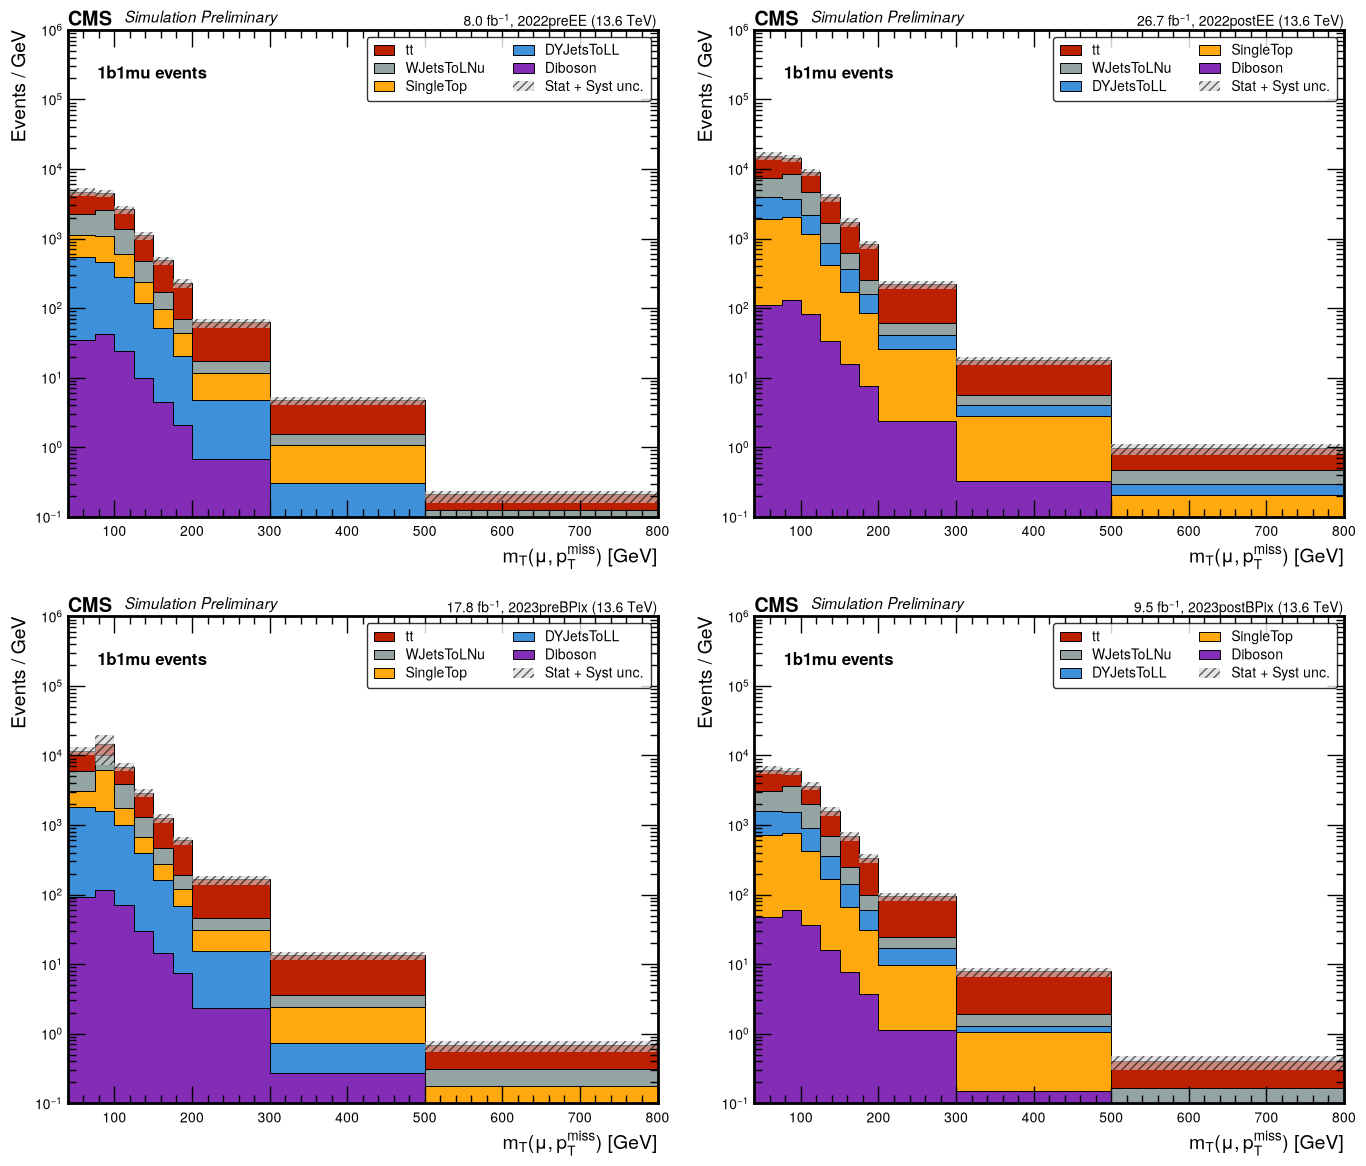

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import yaml
from pathlib import Path
import hist
import mplhep as hep

# Estilo CMS y años de Run 3
hep.style.use(hep.style.CMS)
energy = {"run2": "13 TeV", "run3": "13.6 TeV"}
years = ["2022preEE", "2022postEE", "2023preBPix", "2023postBPix"]

with open(f"{Path.cwd()}/analysis/postprocess/luminosity.yaml", "r") as f:
    luminosities = yaml.safe_load(f)

plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 12,
    "axes.labelsize": 14,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "lines.markersize": 4,
    "legend.fontsize": 10,
})

class CoffeaPlotter:
    def __init__(self, workflow, year, processed_histograms, output_dir):
        self.workflow = workflow
        self.year = year
        self.processed_histograms = processed_histograms
        self.output_dir = output_dir
        builder = WorkflowConfigBuilder(workflow=workflow)
        self.config = builder.build_workflow_config()
        
        path = Path.cwd() / "analysis" / "postprocess"
        with open(path / "style.yaml") as f: 
            self.style = yaml.safe_load(f)
        with open(path / "color_map.yaml") as f: 
            cmap = yaml.safe_load(f)
            
        procs, _, _ = get_process_maps(self.config, year)
        self.color_map = {p: c for p, c in cmap.items() if p in procs and not p.startswith("Wpb")}
        self.color_map["QCD"] = "#FFC0CB" 
        self.signal_color_map = {p: c for p, c in cmap.items() if p.startswith("Wpb")}

    def collect_and_project(self, main_key, var_axis, category):
        h_info = {
            "mc": {"hists": [], "labels": [], "colors": [], "variations": {}}, 
            "signal": {"hists": [], "labels": [], "colors": []}, 
            "data": None
        }
        
        all_variations = set()
        for proc, h_dict in self.processed_histograms.items():
            h = h_dict.get(main_key)
            if h is not None and "variation" in h.axes.name:
                for var in h.axes["variation"]:
                    if var != "nominal":
                        all_variations.add(var)

        for proc, h_dict in self.processed_histograms.items():
            h = h_dict.get(main_key)
            if h is None: continue
            
            sel = {}
            if "variation" in h.axes.name: sel["variation"] = "nominal"
            if "category" in h.axes.name: sel["category"] = category
            
            temp_h = h[sel]
            if var_axis in temp_h.axes.name:
                temp_h = temp_h.project(var_axis)
                
            widths = temp_h.axes[0].widths
            vals = temp_h.values() / widths
            vars_ = temp_h.variances() / (widths**2)
            
            h_norm = hist.Hist(temp_h.axes[0], storage=hist.storage.Weight())
            h_norm.view()[:] = np.stack([vals, vars_], axis=-1)
                
            if proc == "Data":
                h_info["data"] = h_norm
            elif proc.startswith("Wpb"):
                h_info["signal"]["hists"].append(h_norm)
                h_info["signal"]["labels"].append(proc)
                h_info["signal"]["colors"].append(self.signal_color_map.get(proc, "black"))
            else:
                h_info["mc"]["hists"].append(h_norm)
                h_info["mc"]["labels"].append(proc)
                h_info["mc"]["colors"].append(self.color_map.get(proc, "gray"))

        for var in all_variations:
            accum_var_h = None
            for proc, h_dict in self.processed_histograms.items():
                if proc == "Data" or proc.startswith("Wpb"): 
                    continue
                
                h = h_dict.get(main_key)
                if h is None or "variation" not in h.axes.name or var not in h.axes["variation"]: 
                    continue
                
                sel = {"variation": var}
                if "category" in h.axes.name: sel["category"] = category
                
                temp_h = h[sel]
                if var_axis in temp_h.axes.name:
                    temp_h = temp_h.project(var_axis)
                
                widths = temp_h.axes[0].widths
                vals = temp_h.values() / widths
                vars_ = temp_h.variances() / (widths**2)
                
                h_norm = hist.Hist(temp_h.axes[0], storage=hist.storage.Weight())
                h_norm.view()[:] = np.stack([vals, vars_], axis=-1)
                
                if accum_var_h is None:
                    accum_var_h = h_norm
                else:
                    accum_var_h += h_norm
            
            if accum_var_h is not None:
                h_info["mc"]["variations"][var] = accum_var_h

        return h_info

    def plot_uncert_band(self, histogram_info, ax):
        safe_bins = self.nominal_values > 1e-3
        
        if histogram_info["mc"]["variations"]:
            mcstat_err2 = self.nominal_variances
            err2_up = mcstat_err2.copy()
            err2_down = mcstat_err2.copy()
            
            unique_vars = set(k[:-2] for k in histogram_info["mc"]["variations"].keys() if k.endswith("Up") or k.endswith("Down"))
            
            for variation in unique_vars:
                up_key = f"{variation}Up"
                down_key = f"{variation}Down"
                
                if up_key in histogram_info["mc"]["variations"] and down_key in histogram_info["mc"]["variations"]:
                    var_up = histogram_info["mc"]["variations"][up_key].values()
                    var_down = histogram_info["mc"]["variations"][down_key].values()
                    
                    err_up = var_up - self.nominal_values
                    err_down = var_down - self.nominal_values
                    max_delta = self.nominal_values
                    err_up = np.clip(err_up, -max_delta, max_delta)
                    err_down = np.clip(err_down, -max_delta, max_delta)
                    
                    up_is_up = err_up > 0
                    down_is_down = err_down < 0
                    is_onesided = up_is_up ^ down_is_down
                    
                    err2_up_twosided = np.where(up_is_up, err_up**2, err_down**2)
                    err2_down_twosided = np.where(up_is_up, err_down**2, err_up**2)
                    err2_max = np.maximum(err2_up_twosided, err2_down_twosided)
                    
                    err2_up_onesided = np.where(is_onesided & up_is_up, err2_max, 0)
                    err2_down_onesided = np.where(is_onesided & down_is_down, err2_max, 0)
                    
                    err2_up_combined = np.where(is_onesided, err2_up_onesided, err2_up_twosided)
                    err2_down_combined = np.where(is_onesided, err2_down_onesided, err2_down_twosided)
                    
                    err2_up += err2_up_combined
                    err2_down += err2_down_combined
        else:
            err2_up = self.nominal_variances
            err2_down = self.nominal_variances
            
        self.band_up = self.nominal_values + np.sqrt(err2_up)
        
        sigma_down = np.sqrt(err2_down)
        self.band_down = np.where(
            sigma_down < self.nominal_values,
            self.nominal_values - sigma_down,
            self.nominal_values * 0.05
        )
        self.band_down = np.maximum(self.band_down, 1e-2)

        band_args = self.style.get("uncert_band_kwargs", {
            "label": "Stat + Syst unc.",
            "hatch": "//////",
            "facecolor": "none",
            "edgecolor": "black",
            "alpha": 0.4
        }).copy()
        
        ax.bar(
            x=self.centers[safe_bins],
            height=(self.band_up - self.band_down)[safe_bins],
            width=self.widths[safe_bins],
            bottom=self.band_down[safe_bins],
            **band_args,
        )

    def plot_histograms(self, main_key, var_axis, category, ax, log=True):
        plt.rcParams.update(self.style.get("rcParams", {}))
        
        h_info = self.collect_and_project(main_key, var_axis, category)
        mc_hists = h_info["mc"]["hists"]
        total_mc = sum(mc_hists)
        
        self.nominal_values = total_mc.values()
        self.nominal_variances = total_mc.variances()
        self.centers = total_mc.axes[0].centers
        self.widths = total_mc.axes[0].widths

        mc_stk_args = self.style.get("mc_hist_kwargs", {}).copy()
        mc_stk_args.pop("stack", None)
        mc_stk_args.pop("edgecolor", None)

        hep.histplot(
            mc_hists, 
            label=h_info["mc"]["labels"], 
            color=h_info["mc"]["colors"], 
            stack=True, 
            ax=ax, 
            edgecolor="black",
            **mc_stk_args
        )
        self.plot_uncert_band(h_info, ax)
        if h_info["signal"]["hists"]:
            for h_sig, label, color in zip(h_info["signal"]["hists"], h_info["signal"]["labels"], h_info["signal"]["colors"]):
                hep.histplot(
                    h_sig, label=label, color=color, histtype='step', ax=ax, linewidth=1.5
                )
                ax.plot(
                    h_sig.axes[0].centers, h_sig.values(), 
                    marker="+", color=color, linestyle="None", markersize=10
                )
        if h_info["data"]:
            hep.histplot(
                h_info["data"], label="Data", ax=ax, histtype='errorbar',
                color="black", marker="o", markersize=6
            )
            
        edges = total_mc.axes[0].edges
        if log:
            ax.set_yscale("log")
            ax.set_ylim(1e-1, 1e6)
        
        ax.set_xlim(edges[0], edges[-1])
        ax.tick_params(direction="in", top=True, right=True)
        
        ax.legend(ncol=2, fontsize=10, loc="upper right", frameon=True, edgecolor="black", labelspacing=0.3)
        
        lumi_val = luminosities[self.year] * 1e-3
        hep.cms.label("Preliminary", data=False, lumi=f"{lumi_val:.1f}", year=self.year, com=13.6, ax=ax, fontsize=11)
        
        ax.set_ylabel("Events / GeV", fontsize=14)
        ax.set_xlabel(r"$m_T(\mu, p_T^{\mathrm{miss}})$ [GeV]" if "mu" in category else r"$m_T(e, p_T^{\mathrm{miss}})$ [GeV]", fontsize=14)
        ax.text(0.05, 0.90, f"{category}", transform=ax.transAxes, fontsize=12, fontweight='bold')


# -----------------------------------------------------------------
# Configuración y Ejecución Principal (Run 3)
# -----------------------------------------------------------------
sr_to_cr = {
    "1b1mu": "2b1mu",
    "1b1e": "2b1e",
}

main_key = "mass"
sr_workflow = "1b1mu"
cr_workflow = sr_to_cr[sr_workflow]

channel = "muon" if "mu" in sr_workflow else "electron"
variable_axis = f"{channel}_met_mass"
category_signal = f"{sr_workflow} events"

fig, axes = plt.subplots(2, 2, figsize=(14, 12), sharex=False, sharey=False)
grid_indices = [(0, 0), (0, 1), (1, 0), (1, 1)]

for year, (row, col) in zip(years, grid_indices):
    ax = axes[row, col]

    # 1. Ajuste polinómico en la Control Region (CR)
    out_cr = load_hists(year, cr_workflow)
    mc_non_tt_cr = accumulate(
        [out_cr[p][main_key] for p in procs if p in out_cr and p != "tt"]
    )
    data_cr_nom = out_cr["Data"][main_key][
        {"variation": "nominal"}
    ].project(variable_axis)

    edges_cr = data_cr_nom.axes[0].edges
    centers_cr = 0.5 * (edges_cr[:-1] + edges_cr[1:])

    data_vals_cr = data_cr_nom.values()
    vals_non_tt_cr, var_non_tt_cr = get_total_mc_uncertainty(
        mc_non_tt_cr, target_axis=variable_axis
    )
    vals_tt_cr, var_tt_cr = get_total_mc_uncertainty(
        out_cr["tt"][main_key], target_axis=variable_axis
    )

    D_cr = data_vals_cr - vals_non_tt_cr
    M_cr = vals_tt_cr + 1e-32
    accpt_cr = D_cr / M_cr

    var_D_cr = (
        data_cr_nom.variances()
        if data_cr_nom.variances() is not None
        else data_vals_cr
    ) + var_non_tt_cr
    accpt_var_cr = (var_D_cr / (M_cr**2)) + (
        (D_cr**2 * var_tt_cr) / (M_cr**4)
    )
    yerr_accpt_cr = np.sqrt(np.maximum(accpt_var_cr, 0))

    valid_mask = (
        (M_cr > 1e-5)
        & (yerr_accpt_cr > 0)
        & ~np.isnan(accpt_cr)
        & ~np.isinf(accpt_cr)
    )

    best_degree, optimal_coefs, _ = find_optimal_tf_poly(
        centers_cr[valid_mask],
        accpt_cr[valid_mask],
        yerr_accpt_cr[valid_mask],
        max_degree=5,
        alpha=0.05,
    )

    # 2. Cargar SR e Inyectar Corrección en ttbar
    out_signal = load_hists(year, sr_workflow)
    h_tt_sr = out_signal["tt"][main_key]

    proj_tmp = (
        h_tt_sr[{"variation": "nominal"}]
        if "variation" in h_tt_sr.axes.name
        else h_tt_sr
    )
    if "category" in proj_tmp.axes.name:
        cat_val = (
            category_signal
            if category_signal in proj_tmp.axes["category"]
            else 0
        )
        proj_tmp = proj_tmp[{"category": cat_val}]
    proj_tmp = proj_tmp.project(variable_axis)

    centers_sr = proj_tmp.axes[0].centers

    sf_bin = np.polyval(optimal_coefs, centers_sr)
    sf_bin = np.clip(sf_bin, 0.01, 5.0)

    # Inyección in-place usando la vista sin flow
    axis_idx = h_tt_sr.axes.name.index(variable_axis)
    slicer = [slice(None)] * len(h_tt_sr.axes)

    reshape_pattern = [1] * len(h_tt_sr.axes)
    reshape_pattern[axis_idx] = len(sf_bin)
    sf_reshaped = sf_bin.reshape(reshape_pattern)

    view = h_tt_sr.view(flow=False)
    view["value"][tuple(slicer)] *= sf_reshaped
    view["variance"][tuple(slicer)] *= sf_reshaped**2

    # 3. Graficar mediante CoffeaPlotter
    plotter = CoffeaPlotter(
        workflow=sr_workflow,
        year=year,
        processed_histograms=out_signal,
        output_dir="./plots",
    )
    plotter.plot_histograms(
        main_key, variable_axis, category_signal, ax=ax, log=True
    )

plt.tight_layout()
plt.savefig(f"signal_regions_Run3_{sr_workflow}_corrected_Grid.png", dpi=300)
plt.show()

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import yaml
from pathlib import Path
import hist
import mplhep as hep

# Estilo CMS y años de Run 3
hep.style.use(hep.style.CMS)
energy = {"run2": "13 TeV", "run3": "13.6 TeV"}
years = ["2022preEE", "2022postEE", "2023preBPix", "2023postBPix"]

# Crear directorio de salida si no existe
output_dir = Path("./plots")
output_dir.mkdir(parents=True, exist_ok=True)

with open(f"{Path.cwd()}/analysis/postprocess/luminosity.yaml", "r") as f:
    luminosities = yaml.safe_load(f)

plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 12,
    "axes.labelsize": 14,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "lines.markersize": 4,
    "legend.fontsize": 10,
})

class CoffeaPlotter:
    def __init__(self, workflow, year, processed_histograms, output_dir):
        self.workflow = workflow
        self.year = year
        self.processed_histograms = processed_histograms
        self.output_dir = output_dir
        builder = WorkflowConfigBuilder(workflow=workflow)
        self.config = builder.build_workflow_config()
        
        path = Path.cwd() / "analysis" / "postprocess"
        with open(path / "style.yaml") as f: 
            self.style = yaml.safe_load(f)
        with open(path / "color_map.yaml") as f: 
            cmap = yaml.safe_load(f)
            
        procs, _, _ = get_process_maps(self.config, year)
        self.color_map = {p: c for p, c in cmap.items() if p in procs and not p.startswith("Wpb")}
        self.color_map["QCD"] = "#FFC0CB" 
        self.signal_color_map = {p: c for p, c in cmap.items() if p.startswith("Wpb")}

    def collect_and_project(self, main_key, var_axis, category):
        h_info = {
            "mc": {"hists": [], "labels": [], "colors": [], "variations": {}}, 
            "signal": {"hists": [], "labels": [], "colors": []}, 
            "data": None
        }
        
        all_variations = set()
        for proc, h_dict in self.processed_histograms.items():
            h = h_dict.get(main_key)
            if h is not None and "variation" in h.axes.name:
                for var in h.axes["variation"]:
                    if var != "nominal":
                        all_variations.add(var)

        for proc, h_dict in self.processed_histograms.items():
            h = h_dict.get(main_key)
            if h is None: continue
            
            sel = {}
            if "variation" in h.axes.name: sel["variation"] = "nominal"
            if "category" in h.axes.name: sel["category"] = category
            
            temp_h = h[sel]
            if var_axis in temp_h.axes.name:
                temp_h = temp_h.project(var_axis)
                
            widths = temp_h.axes[0].widths
            vals = temp_h.values() / widths
            vars_ = temp_h.variances() / (widths**2)
            
            h_norm = hist.Hist(temp_h.axes[0], storage=hist.storage.Weight())
            h_norm.view()[:] = np.stack([vals, vars_], axis=-1)
                
            if proc == "Data":
                h_info["data"] = h_norm
            elif proc.startswith("Wpb"):
                h_info["signal"]["hists"].append(h_norm)
                h_info["signal"]["labels"].append(proc)
                h_info["signal"]["colors"].append(self.signal_color_map.get(proc, "black"))
            else:
                h_info["mc"]["hists"].append(h_norm)
                h_info["mc"]["labels"].append(proc)
                h_info["mc"]["colors"].append(self.color_map.get(proc, "gray"))

        for var in all_variations:
            accum_var_h = None
            for proc, h_dict in self.processed_histograms.items():
                if proc == "Data" or proc.startswith("Wpb"): 
                    continue
                
                h = h_dict.get(main_key)
                if h is None or "variation" not in h.axes.name or var not in h.axes["variation"]: 
                    continue
                
                sel = {"variation": var}
                if "category" in h.axes.name: sel["category"] = category
                
                temp_h = h[sel]
                if var_axis in temp_h.axes.name:
                    temp_h = temp_h.project(var_axis)
                
                widths = temp_h.axes[0].widths
                vals = temp_h.values() / widths
                vars_ = temp_h.variances() / (widths**2)
                
                h_norm = hist.Hist(temp_h.axes[0], storage=hist.storage.Weight())
                h_norm.view()[:] = np.stack([vals, vars_], axis=-1)
                
                if accum_var_h is None:
                    accum_var_h = h_norm
                else:
                    accum_var_h += h_norm
            
            if accum_var_h is not None:
                h_info["mc"]["variations"][var] = accum_var_h

        return h_info

    def plot_uncert_band(self, histogram_info, ax):
        safe_bins = self.nominal_values > 1e-3
        
        if histogram_info["mc"]["variations"]:
            mcstat_err2 = self.nominal_variances
            err2_up = mcstat_err2.copy()
            err2_down = mcstat_err2.copy()
            
            unique_vars = set(k[:-2] for k in histogram_info["mc"]["variations"].keys() if k.endswith("Up") or k.endswith("Down"))
            
            for variation in unique_vars:
                up_key = f"{variation}Up"
                down_key = f"{variation}Down"
                
                if up_key in histogram_info["mc"]["variations"] and down_key in histogram_info["mc"]["variations"]:
                    var_up = histogram_info["mc"]["variations"][up_key].values()
                    var_down = histogram_info["mc"]["variations"][down_key].values()
                    
                    err_up = var_up - self.nominal_values
                    err_down = var_down - self.nominal_values
                    max_delta = self.nominal_values
                    err_up = np.clip(err_up, -max_delta, max_delta)
                    err_down = np.clip(err_down, -max_delta, max_delta)
                    
                    up_is_up = err_up > 0
                    down_is_down = err_down < 0
                    is_onesided = up_is_up ^ down_is_down
                    
                    err2_up_twosided = np.where(up_is_up, err_up**2, err_down**2)
                    err2_down_twosided = np.where(up_is_up, err_down**2, err_up**2)
                    err2_max = np.maximum(err2_up_twosided, err2_down_twosided)
                    
                    err2_up_onesided = np.where(is_onesided & up_is_up, err2_max, 0)
                    err2_down_onesided = np.where(is_onesided & down_is_down, err2_max, 0)
                    
                    err2_up_combined = np.where(is_onesided, err2_up_onesided, err2_up_twosided)
                    err2_down_combined = np.where(is_onesided, err2_down_onesided, err2_down_twosided)
                    
                    err2_up += err2_up_combined
                    err2_down += err2_down_combined
        else:
            err2_up = self.nominal_variances
            err2_down = self.nominal_variances
            
        self.band_up = self.nominal_values + np.sqrt(err2_up)
        
        sigma_down = np.sqrt(err2_down)
        self.band_down = np.where(
            sigma_down < self.nominal_values,
            self.nominal_values - sigma_down,
            self.nominal_values * 0.05
        )
        self.band_down = np.maximum(self.band_down, 1e-2)

        band_args = self.style.get("uncert_band_kwargs", {
            "label": "Stat + Syst unc.",
            "hatch": "//////",
            "facecolor": "none",
            "edgecolor": "black",
            "alpha": 0.4
        }).copy()
        
        ax.bar(
            x=self.centers[safe_bins],
            height=(self.band_up - self.band_down)[safe_bins],
            width=self.widths[safe_bins],
            bottom=self.band_down[safe_bins],
            **band_args,
        )

    def plot_histograms(self, main_key, var_axis, category, ax, log=True):
        plt.rcParams.update(self.style.get("rcParams", {}))
        
        h_info = self.collect_and_project(main_key, var_axis, category)
        mc_hists = h_info["mc"]["hists"]
        total_mc = sum(mc_hists)
        
        self.nominal_values = total_mc.values()
        self.nominal_variances = total_mc.variances()
        self.centers = total_mc.axes[0].centers
        self.widths = total_mc.axes[0].widths

        mc_stk_args = self.style.get("mc_hist_kwargs", {}).copy()
        mc_stk_args.pop("stack", None)
        mc_stk_args.pop("edgecolor", None)

        hep.histplot(
            mc_hists, 
            label=h_info["mc"]["labels"], 
            color=h_info["mc"]["colors"], 
            stack=True, 
            ax=ax, 
            edgecolor="black",
            **mc_stk_args
        )
        self.plot_uncert_band(h_info, ax)
        if h_info["signal"]["hists"]:
            for h_sig, label, color in zip(h_info["signal"]["hists"], h_info["signal"]["labels"], h_info["signal"]["colors"]):
                hep.histplot(
                    h_sig, label=label, color=color, histtype='step', ax=ax, linewidth=1.5
                )
                ax.plot(
                    h_sig.axes[0].centers, h_sig.values(), 
                    marker="+", color=color, linestyle="None", markersize=10
                )
        if h_info["data"]:
            hep.histplot(
                h_info["data"], label="Data", ax=ax, histtype='errorbar',
                color="black", marker="o", markersize=6
            )
            
        edges = total_mc.axes[0].edges
        if log:
            ax.set_yscale("log")
            ax.set_ylim(1e-1, 1e6)
        
        ax.set_xlim(edges[0], edges[-1])
        ax.tick_params(direction="in", top=True, right=True)
        
        ax.legend(ncol=2, fontsize=10, loc="upper right", frameon=True, edgecolor="black", labelspacing=0.3)
        
        lumi_val = luminosities[self.year] * 1e-3
        hep.cms.label("Preliminary", data=False, lumi=f"{lumi_val:.1f}", year=self.year, com=13.6, ax=ax, fontsize=11)
        
        ax.set_ylabel("Events / GeV", fontsize=14)
        ax.set_xlabel(r"$m_T(\mu, p_T^{\mathrm{miss}})$ [GeV]" if "mu" in category else r"$m_T(e, p_T^{\mathrm{miss}})$ [GeV]", fontsize=14)
        ax.text(0.05, 0.90, f"{category}", transform=ax.transAxes, fontsize=12, fontweight='bold')


# -----------------------------------------------------------------
# Configuración Múltiple (SR -> Lista de CRs)
# -----------------------------------------------------------------
sr_to_crs = {
    "1b1mu": ["2b1mu", "1b1mu1e"],
    "1b1e":  ["2b1e",  "1b1e1mu"]
}

main_key = "mass"

# Bucle anidado para recorrer SRs, CRs y Años
for sr_workflow, cr_workflows in sr_to_crs.items():
    channel = "muon" if "mu" in sr_workflow else "electron"
    variable_axis = f"{channel}_met_mass"
    category_signal = f"{sr_workflow} events"

    for cr_workflow in cr_workflows:
        for year in years:
            fig, ax = plt.subplots(figsize=(8, 7))

            # 1. Ajuste polinómico en la Control Region (CR) correspondiente
            out_cr = load_hists(year, cr_workflow)
            mc_non_tt_cr = accumulate(
                [out_cr[p][main_key] for p in procs if p in out_cr and p != "tt"]
            )
            data_cr_nom = out_cr["Data"][main_key][
                {"variation": "nominal"}
            ].project(variable_axis)

            edges_cr = data_cr_nom.axes[0].edges
            centers_cr = 0.5 * (edges_cr[:-1] + edges_cr[1:])

            data_vals_cr = data_cr_nom.values()
            vals_non_tt_cr, var_non_tt_cr = get_total_mc_uncertainty(
                mc_non_tt_cr, target_axis=variable_axis
            )
            vals_tt_cr, var_tt_cr = get_total_mc_uncertainty(
                out_cr["tt"][main_key], target_axis=variable_axis
            )

            D_cr = data_vals_cr - vals_non_tt_cr
            M_cr = vals_tt_cr + 1e-32
            accpt_cr = D_cr / M_cr

            var_D_cr = (
                data_cr_nom.variances()
                if data_cr_nom.variances() is not None
                else data_vals_cr
            ) + var_non_tt_cr
            accpt_var_cr = (var_D_cr / (M_cr**2)) + (
                (D_cr**2 * var_tt_cr) / (M_cr**4)
            )
            yerr_accpt_cr = np.sqrt(np.maximum(accpt_var_cr, 0))

            valid_mask = (
                (M_cr > 1e-5)
                & (yerr_accpt_cr > 0)
                & ~np.isnan(accpt_cr)
                & ~np.isinf(accpt_cr)
            )

            best_degree, optimal_coefs, _ = find_optimal_tf_poly(
                centers_cr[valid_mask],
                accpt_cr[valid_mask],
                yerr_accpt_cr[valid_mask],
                max_degree=5,
                alpha=0.05,
            )

            # 2. Cargar SR e Inyectar Corrección en ttbar
            out_signal = load_hists(year, sr_workflow)
            h_tt_sr = out_signal["tt"][main_key]

            proj_tmp = (
                h_tt_sr[{"variation": "nominal"}]
                if "variation" in h_tt_sr.axes.name
                else h_tt_sr
            )
            if "category" in proj_tmp.axes.name:
                cat_val = (
                    category_signal
                    if category_signal in proj_tmp.axes["category"]
                    else 0
                )
                proj_tmp = proj_tmp[{"category": cat_val}]
            proj_tmp = proj_tmp.project(variable_axis)

            centers_sr = proj_tmp.axes[0].centers

            sf_bin = np.polyval(optimal_coefs, centers_sr)
            sf_bin = np.clip(sf_bin, 0.01, 5.0)

            # Inyección in-place usando la vista sin flow
            axis_idx = h_tt_sr.axes.name.index(variable_axis)
            slicer = [slice(None)] * len(h_tt_sr.axes)

            reshape_pattern = [1] * len(h_tt_sr.axes)
            reshape_pattern[axis_idx] = len(sf_bin)
            sf_reshaped = sf_bin.reshape(reshape_pattern)

            view = h_tt_sr.view(flow=False)
            view["value"][tuple(slicer)] *= sf_reshaped
            view["variance"][tuple(slicer)] *= sf_reshaped**2

            # 3. Graficar mediante CoffeaPlotter
            plotter = CoffeaPlotter(
                workflow=sr_workflow,
                year=year,
                processed_histograms=out_signal,
                output_dir="./plots",
            )
            plotter.plot_histograms(
                main_key, variable_axis, category_signal, ax=ax, log=True
            )

            # 4. Guardar archivo nombrado explícitamente por SR, Channel, CR y Año
            save_path = f"plots/{sr_workflow}_{channel}_met_mass_ttbar_corrected_via_{cr_workflow}_{year}.png"
            plt.tight_layout()
            plt.savefig(save_path, dpi=300)
            plt.close(fig)

In [10]:
import os
import re
import shutil
import subprocess
import tempfile
import hist
import numpy as np


def get_process_yield_and_errors(h_proc):
    """Calcula el Yield nominal, el error estadístico y el error sistemático.

    Integrando sobre todos los bins para preservar las correlaciones.
    """
    if "variation" in h_proc.axes.name:
        h_nom = h_proc[{"variation": "nominal"}]
    else:
        h_nom = h_proc

    val_nom = float(np.sum(h_nom.values()))

    if h_nom.variances() is not None:
        var_stat = float(np.sum(h_nom.variances()))
    else:
        var_stat = val_nom

    err2_syst_up = 0.0
    err2_syst_down = 0.0

    if "variation" in h_proc.axes.name:
        var_axis = h_proc.axes["variation"]
        variations = set()
        for name in var_axis:
            if name == "nominal":
                continue
            base_name = name.replace("Up", "").replace("Down", "")
            variations.add(base_name)

        for syst in variations:
            up_key = f"{syst}Up"
            down_key = f"{syst}Down"

            val_up = (
                float(np.sum(h_proc[{"variation": up_key}].values()))
                if up_key in var_axis
                else val_nom
            )
            val_down = (
                float(np.sum(h_proc[{"variation": down_key}].values()))
                if down_key in var_axis
                else val_nom
            )

            delta_up = val_up - val_nom
            delta_down = val_down - val_nom

            if delta_up * delta_down < 0:
                d_up = delta_up if delta_up > 0 else -delta_down
                d_down = -delta_down if delta_down < 0 else delta_up
            else:
                max_delta = max(abs(delta_up), abs(delta_down))
                d_up = max_delta if delta_up > 0 else 0.0
                d_down = max_delta if delta_down < 0 else 0.0

            err2_syst_up += d_up**2
            err2_syst_down += d_down**2

    err_syst_global = np.sqrt(max(err2_syst_up, err2_syst_down))

    return val_nom, np.sqrt(var_stat), err_syst_global


def generate_latex_table_corrected(
    out_signal,
    optimal_coefs,
    procs_order,
    year="2022preEE",
    sr_workflow="1b1mu",
    cr_workflow="2b1mu",
):
    channel = "muon" if "mu" in sr_workflow else "electron"
    variable_axis = f"{channel}_met_mass"
    category_signal = f"{sr_workflow} events"
    main_key = "mass"

    yields_uncorrected = {}
    yields_corrected = {}

    # 1. Extraer Yields sin corregir (Nominal, Stat, Syst)
    for p in procs_order:
        if p in out_signal:
            h_proc = out_signal[p][main_key]
            val, stat, syst = get_process_yield_and_errors(h_proc)
            yields_uncorrected[p] = {"val": val, "stat": stat, "syst": syst}

    # Copia para aplicar la corrección in-place a ttbar
    h_tt_sr = out_signal["tt"][main_key]

    proj_tmp = (
        h_tt_sr[{"variation": "nominal"}]
        if "variation" in h_tt_sr.axes.name
        else h_tt_sr
    )
    if "category" in proj_tmp.axes.name:
        cat_val = (
            category_signal
            if category_signal in proj_tmp.axes["category"]
            else 0
        )
        proj_tmp = proj_tmp[{"category": cat_val}]
    proj_tmp = proj_tmp.project(variable_axis)

    centers_sr = proj_tmp.axes[0].centers
    sf_bin = np.polyval(optimal_coefs, centers_sr)
    sf_bin = np.clip(sf_bin, 0.01, 5.0)

    # Inyección in-place para la versión corregida
    axis_idx = h_tt_sr.axes.name.index(variable_axis)
    slicer = [slice(None)] * len(h_tt_sr.axes)
    reshape_pattern = [1] * len(h_tt_sr.axes)
    reshape_pattern[axis_idx] = len(sf_bin)
    sf_reshaped = sf_bin.reshape(reshape_pattern)

    view = h_tt_sr.view(flow=False)
    view["value"][tuple(slicer)] *= sf_reshaped
    view["variance"][tuple(slicer)] *= sf_reshaped**2

    # Extraer Yields corregidos (Nominal, Stat, Syst)
    for p in procs_order:
        if p in out_signal:
            h_proc = out_signal[p][main_key]
            val, stat, syst = get_process_yield_and_errors(h_proc)
            yields_corrected[p] = {"val": val, "stat": stat, "syst": syst}

    # Totales Uncorrected
    total_val_uncorr = sum(y["val"] for y in yields_uncorrected.values())
    total_stat_uncorr = np.sqrt(
        sum(y["stat"] ** 2 for y in yields_uncorrected.values())
    )
    total_syst_uncorr = np.sqrt(
        sum(y["syst"] ** 2 for y in yields_uncorrected.values())
    )

    # Totales Corrected
    total_val_corr = sum(y["val"] for y in yields_corrected.values())
    total_stat_corr = np.sqrt(
        sum(y["stat"] ** 2 for y in yields_corrected.values())
    )
    total_syst_corr = np.sqrt(
        sum(y["syst"] ** 2 for y in yields_corrected.values())
    )

    # 2. Construcción de la tabla LaTeX (2 columnas de datos)
    latex_code = "\\begin{tabular}{@{} l c c @{}}\n"

    title_str = f"\\textbf{{{sr_workflow} (Corrected via {cr_workflow}) --- {year}}}"
    latex_code += f"\\multicolumn{{3}}{{@{{}} l @{{}}}}{{{title_str}}} \\\\[4pt]\n"

    latex_code += "\\hline\n"
    latex_code += " & \\textbf{Events $\\pm$ Stat $\\pm$ Syst} & \\textbf{Percentage} \\\\\n"
    latex_code += "\\hline\n"

    for p in procs_order:
        if p in yields_corrected:
            y_corr = yields_corrected[p]
            y_uncorr = yields_uncorrected[p]
            label_name = r"TTBar" if p == "tt" else p

            pct_corr = (
                (y_corr["val"] / total_val_corr * 100.0)
                if total_val_corr > 0
                else 0.0
            )

            if p == "tt":
                pct_uncorr = (
                    (y_uncorr["val"] / total_val_uncorr * 100.0)
                    if total_val_uncorr > 0
                    else 0.0
                )

                # Formato: ValorNuevo(ValorViejo) \pm StatNuevo(StatViejo) \pm SystNuevo(SystViejo)
                val_str = (
                    f"${y_corr['val']:.2f}({y_uncorr['val']:.2f}) \\pm "
                    f"{y_corr['stat']:.2f}({y_uncorr['stat']:.2f}) \\pm "
                    f"{y_corr['syst']:.2f}({y_uncorr['syst']:.2f})$"
                )
                pct_str = f"${pct_corr:.1f}\\%({pct_uncorr:.1f}\\%)$"
            else:
                pct_uncorr = (
                    (y_uncorr["val"] / total_val_uncorr * 100.0)
                    if total_val_uncorr > 0
                    else 0.0
                )

                val_str = f"${y_corr['val']:.2f} \\pm {y_corr['stat']:.2f} \\pm {y_corr['syst']:.2f}$"
                pct_str = f"${pct_corr:.1f}\\%({pct_uncorr:.1f}\\%)$"

            latex_code += f"{label_name} & {val_str} & {pct_str} \\\\\n"

    latex_code += "\\hline\n"

    # Total MC Background con formato Nuevo(Viejo)
    total_val_str = (
        f"${total_val_corr:.2f}({total_val_uncorr:.2f}) \\pm "
        f"{total_stat_corr:.2f}({total_stat_uncorr:.2f}) \\pm "
        f"{total_syst_corr:.2f}({total_syst_uncorr:.2f})$"
    )

    latex_code += f"Total backg. & {total_val_str} & -- \\\\\n"
    latex_code += "\\hline\n"
    latex_code += "\\end{tabular}\n"

    return latex_code

def compile_latex_to_png(table_code, output_path):
    """Compila usando la clase 'article' extendiendo el tamaño del papel

    para evitar recortes y asegurando compatibilidad nativa sin paquetes extra.
    """
    clean_table_code = re.sub(
        r"\\begin\{table\}(\[.*?\])?", "", table_code
    )
    clean_table_code = re.sub(r"\\end\{table\}", "", clean_table_code)

    tex_template = f"""\\documentclass[12pt]{{article}}
\\usepackage{{amsmath}}
\\usepackage{{amssymb}}
\\usepackage{{array}}
\\usepackage{{booktabs}}
\\usepackage{{graphicx}}
\\usepackage[active,tightpage]{{preview}}

% Configuración manual del ancho de página para evitar recortes por la derecha
\\paperwidth=28cm
\\pdfpagewidth=\\paperwidth
\\paperheight=15cm
\\pdfpageheight=\\paperheight

\\setlength\\PreviewBorder{{10pt}}

\\begin{{document}}
\\begin{{preview}}
\\resizebox{{\\linewidth}}{{!}}{{
{clean_table_code}
}}
\\end{{preview}}
\\end{{document}}
"""

    with tempfile.TemporaryDirectory() as tmpdir:
        tex_file = os.path.join(tmpdir, "table.tex")
        pdf_file = os.path.join(tmpdir, "table.pdf")
        png_prefix = os.path.join(tmpdir, "table_out")

        with open(tex_file, "w") as f:
            f.write(tex_template)

        # 1. Compilar LaTeX
        proc = subprocess.run(
            [
                "pdflatex",
                "-interaction=nonstopmode",
                "-output-directory",
                tmpdir,
                tex_file,
            ],
            stdout=subprocess.PIPE,
            stderr=subprocess.PIPE,
            text=True,
        )

        if proc.returncode != 0:
            print("  ❌ Error de compilación en LaTeX:")
            log_file = os.path.join(tmpdir, "table.log")
            if os.path.exists(log_file):
                with open(log_file, "r") as log:
                    for line in log:
                        if line.startswith("!"):
                            print(f"     {line.strip()}")
            return

        # 2. Convertir PDF a PNG
        try:
            subprocess.run(
                ["pdftoppm", "-png", "-r", "300", pdf_file, png_prefix],
                check=True,
                stdout=subprocess.DEVNULL,
                stderr=subprocess.DEVNULL,
            )

            generated_png = f"{png_prefix}-1.png"
            if os.path.exists(generated_png):
                shutil.move(generated_png, output_path)
                print(f"  ✓ PNG guardado correctamente: {output_path}")

        except Exception as e:
            print(f"  ❌ Error convirtiendo PDF a PNG: {e}")

# ==============================================================================
# BUCLE PRINCIPAL
# ==============================================================================
sr_to_crs = {
    "1b1mu": ["2b1mu", "1b1mu1e"],
    "1b1e": ["2b1e", "1b1e1mu"],
}

years = ["2022preEE", "2022postEE", "2023preBPix", "2023postBPix"]
procs = ["DYJetsToLL", "SingleTop", "Diboson", "WJetsToLNu", "tt"]
main_key = "mass"

output_filename = "outputs_corrected_mc.txt"
os.makedirs("plots", exist_ok=True)

with open(output_filename, "w") as f:
    for sr_workflow, cr_workflows in sr_to_crs.items():
        channel = "muon" if "mu" in sr_workflow else "electron"
        variable_axis = f"{channel}_met_mass"

        for cr_workflow in cr_workflows:
            for yr in years:
                print(
                    f"Procesando: SR={sr_workflow} | CR={cr_workflow} | Year={yr}..."
                )

                # 1. Obtención de coeficientes polinómicos en CR
                out_cr = load_hists(yr, cr_workflow)
                mc_non_tt_cr = accumulate(
                    [
                        out_cr[p][main_key]
                        for p in procs
                        if p in out_cr and p != "tt"
                    ]
                )
                data_cr_nom = out_cr["Data"][main_key][
                    {"variation": "nominal"}
                ].project(variable_axis)

                edges_cr = data_cr_nom.axes[0].edges
                centers_cr = 0.5 * (edges_cr[:-1] + edges_cr[1:])

                data_vals_cr = data_cr_nom.values()
                vals_non_tt_cr, var_non_tt_cr = get_total_mc_uncertainty(
                    mc_non_tt_cr, target_axis=variable_axis
                )
                vals_tt_cr, var_tt_cr = get_total_mc_uncertainty(
                    out_cr["tt"][main_key], target_axis=variable_axis
                )

                D_cr = data_vals_cr - vals_non_tt_cr
                M_cr = vals_tt_cr + 1e-32
                accpt_cr = D_cr / M_cr

                var_D_cr = (
                    data_cr_nom.variances()
                    if data_cr_nom.variances() is not None
                    else data_vals_cr
                ) + var_non_tt_cr
                accpt_var_cr = (var_D_cr / (M_cr**2)) + (
                    (D_cr**2 * var_tt_cr) / (M_cr**4)
                )
                yerr_accpt_cr = np.sqrt(np.maximum(accpt_var_cr, 0))

                valid_mask = (
                    (M_cr > 1e-5)
                    & (yerr_accpt_cr > 0)
                    & ~np.isnan(accpt_cr)
                    & ~np.isinf(accpt_cr)
                )

                best_degree, optimal_coefs, _ = find_optimal_tf_poly(
                    centers_cr[valid_mask],
                    accpt_cr[valid_mask],
                    yerr_accpt_cr[valid_mask],
                    max_degree=5,
                    alpha=0.05,
                )

                # 2. Cargar SR
                out_signal = load_hists(yr, sr_workflow)

                # 3. Generar código de la tabla
                table_code = generate_latex_table_corrected(
                    out_signal=out_signal,
                    optimal_coefs=optimal_coefs,
                    procs_order=procs,
                    year=yr,
                    sr_workflow=sr_workflow,
                    cr_workflow=cr_workflow,
                )

                # Escribir en archivo de texto
                f.write(f"% ==========================================\n")
                f.write(
                    f"% SR: {sr_workflow} | CR: {cr_workflow} | Year: {yr}\n"
                )
                f.write(f"% ==========================================\n\n")
                f.write(table_code)
                f.write("\n\n")

                # Generar la imagen PNG con el nuevo formato de nombre solicitado
                table_filename = f"{sr_workflow}_{variable_axis}_ttbar_corrected_via_{cr_workflow}_{yr}_table.png"
                png_path = os.path.join("plots", table_filename)

                compile_latex_to_png(table_code, png_path)

print(
    f"\nProceso finalizado. Tablas guardadas en '{output_filename}' e imágenes en 'plots/'."
)

Procesando: SR=1b1mu | CR=2b1mu | Year=2022preEE...
  ✓ PNG guardado correctamente: plots/1b1mu_muon_met_mass_ttbar_corrected_via_2b1mu_2022preEE_table.png
Procesando: SR=1b1mu | CR=2b1mu | Year=2022postEE...
  ✓ PNG guardado correctamente: plots/1b1mu_muon_met_mass_ttbar_corrected_via_2b1mu_2022postEE_table.png
Procesando: SR=1b1mu | CR=2b1mu | Year=2023preBPix...
  ✓ PNG guardado correctamente: plots/1b1mu_muon_met_mass_ttbar_corrected_via_2b1mu_2023preBPix_table.png
Procesando: SR=1b1mu | CR=2b1mu | Year=2023postBPix...
  ✓ PNG guardado correctamente: plots/1b1mu_muon_met_mass_ttbar_corrected_via_2b1mu_2023postBPix_table.png
Procesando: SR=1b1mu | CR=1b1mu1e | Year=2022preEE...
  ✓ PNG guardado correctamente: plots/1b1mu_muon_met_mass_ttbar_corrected_via_1b1mu1e_2022preEE_table.png
Procesando: SR=1b1mu | CR=1b1mu1e | Year=2022postEE...
  ✓ PNG guardado correctamente: plots/1b1mu_muon_met_mass_ttbar_corrected_via_1b1mu1e_2022postEE_table.png
Procesando: SR=1b1mu | CR=1b1mu1e | Year=2